In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
MODELSDIR = CONFIGS['filepaths']['models']
SRMODELS  = CONFIGS['experiments']['sr']['optimizedeqs']
SPLIT     = 'test'
REGISTRY  = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']),train_loss=row['train_loss'],valid_loss=row['valid_loss'])
            for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}

In [4]:
def predict_from_sr_bl(bl):
    return np.maximum(np.expm1(alpha*(bl-bc)**3+beta),0.0)

def bin_1d(x,z,nbins=25,minsamples=50,plo=1,phi=99):
    mask = np.isfinite(x) & np.isfinite(z)
    x,z  = x[mask],z[mask]
    edges  = np.linspace(*np.percentile(x,[plo,phi]),nbins+1)
    xi     = np.clip(np.digitize(x,edges)-1,0,nbins-1)
    counts = np.bincount(xi,minlength=nbins)
    sums   = np.bincount(xi,weights=z,minlength=nbins)
    return 0.5*(edges[:-1]+edges[1:]),np.where(counts>=minsamples,sums/counts,np.nan),counts

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
blmean = STATS['bl_mean']
blstd  = STATS['bl_std']
tpstd  = STATS['tp_std']
tpmean = STATS['tp_mean']
c1,c2  = REGISTRY['sr_bl_eq']['constants']['c1'],REGISTRY['sr_bl_eq']['constants']['c2']

bc    = blmean-c1*blstd
alpha = tpstd/blstd**3
beta  = tpstd*c2

constdf = pd.DataFrame([
    {'Constant':'$B_c$','Value':f'{bc:.3f}','Units':'m/s²'},
    {'Constant':'$\\alpha$','Value':f'{alpha:,.0f}','Units':'s⁶/m³'},
    {'Constant':'$\\beta$','Value':f'{beta:.3f}','Units':'dimensionless'}])
display(constdf.style.hide(axis='index'))

Constant,Value,Units
$B_c$,-0.096,m/s²
$\alpha$,"1,660",s⁶/m³
$\beta$,0.074,dimensionless


In [6]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    bl = ds['bl'].transpose('time','lat','lon').values.ravel()
    tp = ds['tp'].transpose('time','lat','lon').values.ravel()

finite = np.isfinite(bl)&np.isfinite(tp)
bl = bl[finite]
tp = tp[finite]

blrange = np.linspace(np.percentile(bl,1),np.percentile(bl,99),300)
predtp  = predict_from_sr_bl(blrange)
centers,tpmean,_ = bin_1d(bl,tp,nbins=40)

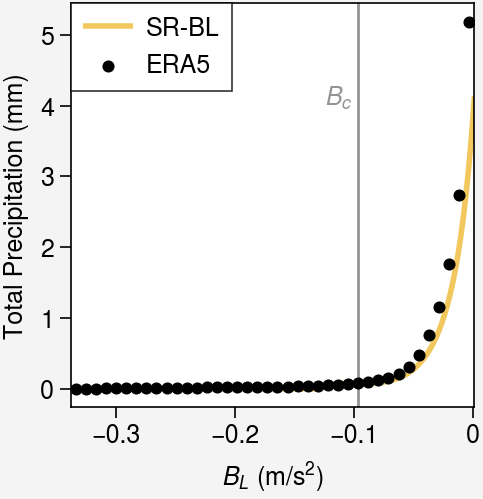

In [7]:
fig,ax = pplt.subplots(figwidth=2.5)
ax.format(grid=False,xlabel='$\\mathit{B_L}$ (m/s$^2$)',ylabel='Total Precipitation (mm)')
ax.plot(blrange,predtp,color=SRMODELS['sr_bl_eq']['color'],linewidth=2,label='SR-BL',zorder=2)
ax.scatter(centers,tpmean,color='k',markersize=14,label='ERA5',zorder=3)
ax.axvline(bc,color='gray',linewidth=1,zorder=1)
ax.text(bc-0.005,0.8,'$\\mathit{B_c}$',ha='right',va='top',color='gray',transform=ax.get_xaxis_transform())
ax.legend(loc='ul',ncols=1)
pplt.show()
fig.save('../figs/fig_2.jpg')